<a href="https://colab.research.google.com/github/Anfizer11/Learning_Shape_and_Color_with_Contrastive_Learning_Exercise/blob/main/shape_and_color_with_contrastive_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project is an independent implementation of a contrastive representation-learning exercise presented in Foundations of Computer Vision by Antonio Torralba, Phillip Isola, and William Freeman, Chapter 30. The textbook defined the experimental objective and general methodology.

My contributions included implementing the synthetic dataset-generation pipeline, convolutional encoder, contrastive loss functions, model-training workflow, nearest-neighbor evaluation, and embedding visualizations contained in this repository.

# 1) Generating the Data

Let’s explore how autoencoders work on a simple data domain, consisting just of colored circles, triangles, and squares. The data consists of 64,000 images, samples of which are shown in Figure 30.4.

Each shape has a randomized size, position, and rotation. Each shape’s color is sampled from one of eight color classes (orange, green, purple, etc.) plus a small random perturbation.

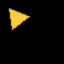

{'shape': 'triangle', 'color_name': 'yellow', 'rotation_deg': 322.06533669351114, 'radius_px': 12.175945901463434, 'center_xy': (17, 18)}


In [ ]:
import math, random
import numpy as np
from PIL import Image, ImageDraw, ImageFilter

# data domain values
SHAPES = ["circle", "triangle", "square"] # (0-2)
COLOR_NAMES = ["red","green","blue","orange","purple","pink","cyan","yellow"] # (0-7)
COLOR_MAP = {
    "red":    (220,  50,  50),
    "green":  ( 60, 200,  70),
    "blue":   ( 60, 110, 220),
    "orange": (245, 150,  40),
    "purple": (150,  80, 190),
    "pink":   (230,  80, 160),
    "cyan":   ( 50, 200, 200),
    "yellow": (240, 220,  70),
}

def perturb_color(rgb, magnitude=15):
    """Small per-image color perturbation."""
    r, g, b = rgb
    j = lambda c: int(np.clip(c + np.random.randint(-magnitude, magnitude+1), 0, 255))
    return (j(r), j(g), j(b))

def make_shape_image(
    img_size=64,
    shape=None,                # "circle", "triangle", or "square" (or None for random)
    color_name=None,           # one of COLOR_NAMES (or None for random)
    rng_seed=None,
):
    # Seed & random choices
    if rng_seed is not None:
        random.seed(rng_seed)
        np.random.seed(rng_seed)
    shape = shape or random.choice(SHAPES)
    color_name = color_name or random.choice(COLOR_NAMES)

    # Color perturbation
    fill = perturb_color(COLOR_MAP[color_name], magnitude=15)

    # Creates image object
    S = img_size
    img = Image.new("RGB", (S, S), (0, 0, 0))
    mask = Image.new("L", (S, S), 0)
    draw = ImageDraw.Draw(mask)

    # Values to handle rotation (Random size as a radius of circumscribed circle in pixels)
    R = random.uniform(0.18, 0.40) * S
    rot = random.uniform(0.0, 360.0)           # in degrees
    margin = int(R + 2)
    cx = random.randint(margin, S - margin)    # centers x
    cy = random.randint(margin, S - margin)    # centers y

    if shape == "circle":
        # draws a bounding box for the circle
        bbox = [cx - R, cy - R, cx + R, cy + R]
        draw.ellipse(bbox, fill=255)

    elif shape == "square":
        a = R / math.sqrt(2.0)
        pts = np.array([[-a, -a], [ a, -a], [ a,  a], [-a,  a]])
        th = math.radians(rot)
        Rm = np.array([[math.cos(th), -math.sin(th)],
                       [math.sin(th),  math.cos(th)]])
        pts = (pts @ Rm.T) + np.array([cx, cy])
        draw.polygon([tuple(p) for p in pts], fill=255)

    elif shape == "triangle":
        s = R * math.sqrt(3.0)
        h = s * math.sqrt(3.0) / 2.0
        pts = np.array([
            [ 0.0, -2.0*h/3.0],
            [-s/2,  h/3.0],
            [ s/2,  h/3.0],
        ])
        th = math.radians(rot)
        Rm = np.array([[math.cos(th), -math.sin(th)],
                       [math.sin(th),  math.cos(th)]])
        pts = (pts @ Rm.T) + np.array([cx, cy])
        draw.polygon([tuple(p) for p in pts], fill=255)

    # anti-aliasing slightly blurs the mask to cut down on jagged edges of shapes
    # Tweak radius ~0.5–0.8 for a 64×64 image
    mask = mask.filter(ImageFilter.GaussianBlur(radius=0.6))

    # adds the colored shape using the mask
    shape_rgb = Image.new("RGB", (S, S), fill)
    img.paste(shape_rgb, mask=mask)

    meta_data = {
            "shape": shape,
            "color_name": color_name,
            "rotation_deg": rot,
            "radius_px": float(R),
            "center_xy": (int(cx), int(cy)),
    }
    return img, meta_data

# creates a sample image
img, metaD = make_shape_image(img_size=64)
display(img)
print(metaD)

In [ ]:
# generates the dataset
import os, csv, random
import numpy as np
from PIL import Image
from tqdm import trange

# To mount to google drive
# from google.colab import drive
# drive.mount('/content/drive')
# OUT_DIR = "/content/drive/MyDrive/autoEncoderDataset"

OUT_DIR = "/content/autoEncoderDataset"
IMG_DIR = os.path.join(OUT_DIR, "images")
os.makedirs(IMG_DIR, exist_ok=True)

NUMBER_OF_IMAGES = 64000
IMG_SIZE = 64
RANDOM_SEED = 1337

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

labels_path = os.path.join(OUT_DIR, "labels.csv")
with open(labels_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "filename", "shape_id", "shape", "color_id", "color_name",
        "rotation_deg", "radius_px", "center_x", "center_y"
    ])

    for i in trange(NUMBER_OF_IMAGES, desc="Generating Images"):
        # randomly chooses shape/color class labels
        shape = random.choice(SHAPES)
        color_name = random.choice(COLOR_NAMES)

        img, metaD = make_shape_image(
            img_size=IMG_SIZE,
            shape=shape,
            color_name=color_name,
        )

        fname = f"{i:06d}.png"
        img.save(os.path.join(IMG_DIR, fname), format="PNG", optimize=True)

        writer.writerow([
            fname,
            SHAPES.index(shape),
            shape,
            COLOR_NAMES.index(color_name),
            color_name,
            round(metaD["rotation_deg"], 3),
            round(metaD["radius_px"], 3),
            int(metaD["center_xy"][0]),
            int(metaD["center_xy"][1]),
        ])
print()
print("Dataset Complete!")
print(f"{NUMBER_OF_IMAGES} Images Generated")
print("File name structure:", sorted(os.listdir(IMG_DIR))[:5])
print("Located in:", labels_path)


Generating Images: 100%|██████████| 64000/64000 [01:30<00:00, 708.91it/s]



Dataset Complete!
64000 Images Generated
File name structure: ['000000.png', '000001.png', '000002.png', '000003.png', '000004.png']
Located in: /content/autoEncoderDataset/labels.csv


Displaying/Graphing the data

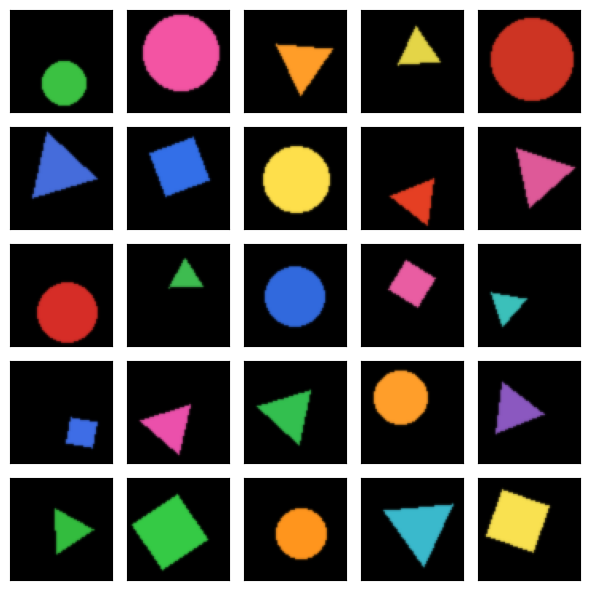

In [ ]:
# Preview a 5x5 grid of random images
import os, glob, random
from PIL import Image
import matplotlib.pyplot as plt

IMG_DIR = "/content/autoEncoderDataset/images"

files = sorted(glob.glob(os.path.join(IMG_DIR, "*.png")))
sample = random.sample(files, k=25)

plt.figure(figsize=(6,6))
for i, fp in enumerate(sample, 1):
    ax = plt.subplot(5,5,i)
    ax.imshow(Image.open(fp).convert("RGB"))
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# 2) Building the model

For the autoencoder architecture we use a convolutional encoder and decoder, each with six convolutional layers interspersed with relu nonlinearities and a 128-dimensional bottleneck (i.e., ). We train this autoencoder for 20,000 steps of stochastic gradient descent, using the Adam optimizer [10] with a batch size of 128.

^old

we will now illustrate how one can design embeddings with desired invariances. We will use the shape dataset described in Section 30.4, and will use the same encoder architecture and optimizer as from that section (a CNN with six layers, Adam optimizer, 20,000 iterations of stochastic gradient descent, batch size of 128). In contrast to the autoencoder experiment, however, we will set the dimensionality of the embedding to M = 2, so that we can visualize it in a 2D plot.

Suppose we wish to obtain an embedding that is sensitive to color and invariant to shape. Then we should choose a view transformation *T_c* that preserves color while changing shape. A simple choice that turns out to work is for **T_c*(**x**)* to simply output a crop from the image ***x*** (this transformation does not really change the object’s shape but still ends up resulting in shape-invariant embeddings because color is a much more obvious cue for the CNN to pick up on and use for solving the contrastive problem). The result of contrastive learning, using *L_align + L_unif* on data generated from *T_c* is shown on the top row of Figure 30.14. Notice that the trained *f* maps colors to be clustered into the color classes of this toy data, and that these classes become spread out more or less uniformly across the surface of a circle in embedding space (a one-dimensional hypersphere, because the embeddings are 2D and normalized).

We can repeat the same experiment but with a view transformation *T_s* designed to be invariant to color. To do so we simply use the same transformation as for *T_c* (i.e., cropping) plus add a random shift in hue, brightness, and saturation. Training on views generated from *T_s* results in the embeddings on the bottom row of Figure 30.14. Now the embeddings become invariant to color but cluster shapes and spread out the three shape types to be roughly uniformly spaced around the hypersphere.

Transform Helpers

In [ ]:
import torchvision.transforms as T

def make_Tc(img_size=64, crop_scale=(0.6, 1.0)):
    """
    Generates a color sensitive transform on an image
    random resized crop
    """
    return T.Compose([
        T.RandomResizedCrop(img_size, scale=crop_scale, antialias=True),
        T.ToTensor(),  # convert to tensor which changes values scaled to [0,1]
    ])


def make_Ts(img_size=64, crop_scale=(0.6, 1.0),
            brightness=0.4, saturation=0.4, hue=0.2):
    """
    Generates a shape sensitive transform
    random resized crop + color jitter
    """
    return T.Compose([
        T.RandomResizedCrop(img_size, scale=crop_scale, antialias=True),
        T.ColorJitter(brightness=brightness, saturation=saturation, hue=hue),
        T.ToTensor(),
    ])

Create loss functions

In [ ]:
import math
import torch
import torch.nn.functional as F

def loss_align(z1, z2, alpha=2):
    # If you prefer to enforce unit length here too:
    # z1 = F.normalize(z1, dim=1); z2 = F.normalize(z2, dim=1)
    return (z1 - z2).norm(p=2, dim=1).pow(alpha).mean()

def loss_unif(z, t=2.0):
    sim = z @ z.t()
    d2 = (2.0 - 2.0 * sim).clamp_min(0) # ||u - v||^2 = 2 - 2 * cos(u, v)
    B = z.size(0)
    # excludes diagonal (i != j)
    mask = ~torch.eye(B, dtype=torch.bool, device=z.device)
    x = -t * d2[mask]
    # log mean exp logsumexp - log(N) is used to be numerically stable
    return torch.logsumexp(x, 0) - math.log(x.numel())

def loss_contrastive(z1, z2, t=2.0, lambda_unif=1.0, align_alpha=2):
    """
    loss from in 30.10.2:
      L = L_align(z1,z2) + lambda_unif * L_unif(concat(z1,z2))
    Returns:
      loss, {'align':..., 'unif':...} for logging
    """
    L_align = loss_align(z1, z2, alpha=align_alpha)
    z_all = torch.cat([z1, z2], dim=0)
    L_unif  = loss_unif(z_all, t=t)
    return L_align + lambda_unif * L_unif, {'align': L_align.item(), 'unif': L_unif.item()}

Create encoder

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Encoder_with_6_layers(nn.Module):
    def __init__(self, emb_dim=2):
        super().__init__()
        C = [32, 64, 128, 128, 128, 128]
        layers, in_ch = [], 3
        for c in C:
            layers += [nn.Conv2d(in_ch, c, 3, padding=1), nn.ReLU(inplace=True)]
            in_ch = c
        self.backbone = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(C[-1], emb_dim)

    def forward(self, x):
        h = self.backbone(x)
        h = self.pool(h).squeeze(-1).squeeze(-1)  # B×C
        z = self.head(h)                          # B×emb_dim
        z = F.normalize(z, dim=1)                 # <<< normalize HERE (unit sphere)
        return z


# 3) Training

After training, does this autoencoder obtain a good representation of the data? To answer this question, we need ways of evaluating the quality of a representation. There are many ways and indeed how to evaluate representations is an open area of research. But here we will stick with a very simple approach: see if the nearest neighbors, in representational space, are meaningful.


We can test this in two ways: (1) for a given query, visualize the images in the dataset whose embeddings are nearest neighbors to the query’s embedding, and (2) measure the accuracy of a one-nearest-neighbor classifier in embedding space.

Train

In [ ]:
import os, glob
import torch
from torch.utils.data import DataLoader, Dataset
from itertools import cycle
from PIL import Image # Import Image here

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# IMG_DIR     = "/content/autoEncoderDataset" # This is overwritten in Z9GqaAd-i47M, keeping for reference
BATCH_SIZE  = 128
STEPS       = 20_000           # 20k updates
LR          = 1e-3
WEIGHT_DECAY= 1e-4
LOG_EVERY   = 200

# reads a PNG and returns a PIL image (label isn't needed)
class FlatImages(Dataset):
    def __init__(self, img_dir):
        self.paths = sorted(glob.glob(os.path.join(img_dir, "*.png")))
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return img, 0

# Wraps a base dataset to return TWO views (x1, x2) for contrastive pairs
class ContrastiveViews(Dataset):
    def __init__(self, base_ds, transform):
        self.base_ds, self.t = base_ds, transform
    def __len__(self): return len(self.base_ds)
    def __getitem__(self, i):
        img, _ = self.base_ds[i]
        return self.t(img), self.t(img)

def build_loader(T_run):
    base = FlatImages(IMG_DIR)
    ds = ContrastiveViews(base, T_run)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)

def _to(x): return x.to(device, non_blocking=True)

In [ ]:
# Two training loops: Tc and Ts
import os, glob
import torch
from torch.utils.data import DataLoader
from itertools import cycle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_DIR     = "/content/autoEncoderDataset/images"
BATCH_SIZE  = 128
STEPS       = 20_000           # 20k updates
LR          = 1e-3
WEIGHT_DECAY= 1e-4
LOG_EVERY   = 200

In [ ]:
# Tc (color-sensitive)
Tc = make_Tc(img_size=64)                              # crop-only
base_tc = FlatImages(IMG_DIR)
ds_tc   = ContrastiveViews(base_tc, transform=Tc)
loader_tc = DataLoader(ds_tc, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=2, pin_memory=True, drop_last=True)

model = Encoder_with_6_layers(emb_dim=2).to(device)    # new model per run
opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

model.train()
it_tc = cycle(loader_tc)                               # infinite batch iterator
for step in range(1, STEPS + 1):
    x1, x2, = next(it_tc)                              # (B,3,64,64) each
    x1 = x1.to(device, non_blocking=True)
    x2 = x2.to(device, non_blocking=True)

    z1 = model(x1)                                     # unit-norm embeddings
    z2 = model(x2)

    loss, logs = loss_contrastive(z1, z2, t=2.0, lambda_unif=1.0, align_alpha=2)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    if step % LOG_EVERY == 0:
        print(f"[Tc] step {step:5d} | loss {loss.item():.4f} "
              f"| align {logs['align']:.4f} | unif {logs['unif']:.4f}")

torch.save(model.state_dict(), "/content/6L_encoder_Tc.pt")

[Tc] step   200 | loss -1.4341 | align 0.0528 | unif -1.4868
[Tc] step   400 | loss -1.5074 | align 0.0402 | unif -1.5476
[Tc] step   600 | loss -1.4985 | align 0.0268 | unif -1.5253
[Tc] step   800 | loss -1.4646 | align 0.0106 | unif -1.4752
[Tc] step  1000 | loss -1.5135 | align 0.0194 | unif -1.5329
[Tc] step  1200 | loss -1.5289 | align 0.0187 | unif -1.5475
[Tc] step  1400 | loss -1.5629 | align 0.0094 | unif -1.5723
[Tc] step  1600 | loss -1.5207 | align 0.0149 | unif -1.5356
[Tc] step  1800 | loss -1.5593 | align 0.0060 | unif -1.5654
[Tc] step  2000 | loss -1.4220 | align 0.0053 | unif -1.4273
[Tc] step  2200 | loss -1.5275 | align 0.0046 | unif -1.5321
[Tc] step  2400 | loss -1.5587 | align 0.0042 | unif -1.5629
[Tc] step  2600 | loss -1.4876 | align 0.0039 | unif -1.4915
[Tc] step  2800 | loss -1.5499 | align 0.0031 | unif -1.5530
[Tc] step  3000 | loss -1.4579 | align 0.0046 | unif -1.4626
[Tc] step  3200 | loss -1.5404 | align 0.0034 | unif -1.5439
[Tc] step  3400 | loss -

In [ ]:
# Ts (shape-sensitive)
Ts = make_Ts(img_size=64)                              # crop + color jitter
base_ts = FlatImages(IMG_DIR)
ds_ts   = ContrastiveViews(base_ts, transform=Ts)
loader_ts = DataLoader(ds_ts, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=2, pin_memory=True, drop_last=True)

model = Encoder_with_6_layers(emb_dim=2).to(device)    # fresh model
opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

model.train()
it_ts = cycle(loader_ts)
for step in range(1, STEPS + 1):
    x1, x2, = next(it_ts)
    x1 = x1.to(device, non_blocking=True)
    x2 = x2.to(device, non_blocking=True)

    z1 = model(x1)
    z2 = model(x2)

    loss, logs = loss_contrastive(z1, z2, t=2.0, lambda_unif=1.0, align_alpha=2)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    if step % LOG_EVERY == 0:
        print(f"[Ts] step {step:5d} | loss {loss.item():.4f} "
              f"| align {logs['align']:.4f} | unif {logs['unif']:.4f}")

torch.save(model.state_dict(), "/content/6L_encoder_Ts.pt")

[Ts] step   200 | loss -0.8616 | align 0.1245 | unif -0.9861
[Ts] step   400 | loss -0.9415 | align 0.1636 | unif -1.1051
[Ts] step   600 | loss -0.7216 | align 0.1664 | unif -0.8880
[Ts] step   800 | loss -0.8917 | align 0.1244 | unif -1.0161
[Ts] step  1000 | loss -0.9238 | align 0.1205 | unif -1.0442
[Ts] step  1200 | loss -0.9275 | align 0.1122 | unif -1.0397
[Ts] step  1400 | loss -0.9439 | align 0.1460 | unif -1.0898
[Ts] step  1600 | loss -0.8693 | align 0.1999 | unif -1.0692
[Ts] step  1800 | loss -0.9162 | align 0.1196 | unif -1.0359
[Ts] step  2000 | loss -0.9979 | align 0.4778 | unif -1.4757
[Ts] step  2200 | loss -1.1293 | align 0.3483 | unif -1.4776
[Ts] step  2400 | loss -1.1049 | align 0.4276 | unif -1.5326
[Ts] step  2600 | loss -1.1451 | align 0.3556 | unif -1.5008
[Ts] step  2800 | loss -0.6860 | align 0.0967 | unif -0.7827
[Ts] step  3000 | loss -0.9443 | align 0.0886 | unif -1.0329
[Ts] step  3200 | loss -1.1540 | align 0.3031 | unif -1.4571
[Ts] step  3400 | loss -

used to download the data set

In [ ]:
# FOLDER = "/content/autoEncoderDataset"
# ZIP_PATH = "/content/autoEncoderDataset.zip"

# # 2) Create a zip (quietly), excluding notebook checkpoints
# !zip -r -q "{ZIP_PATH}" "{FOLDER}" -x "**/.ipynb_checkpoints/*"

# # 3) Download to your computer
# from google.colab import files
# files.download(ZIP_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 4) Analyzing Results

In [ ]:
# evaluates Tc and Ts with the Z-space and nearest neighbors
import os, glob, math, random
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

# paths to model and dataset
IMG_DIR     = "/content/autoEncoderDataset/images"
LABELS_CSV  = "/content/autoEncoderDataset/labels.csv"
CKPT_TC     = "/content/6L_encoder_Tc.pt"   # color sensitive model Tc
CKPT_TS     = "/content/6L_encoder_Ts.pt"   # shape sensitive model Ts

EVAL_SAMPLE = 100    # number of images to scatter
BATCH       = 512
K_NEIGHBORS = 6       # how many neighbors to display per query
N_QUERIES   = 5       # how many query rows we want to display
THUMB       = 64      # resizes each picture displayed in the nearest neighbor graph
PAD         = 6       # padding in nearest neighbor graph

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# evaluation dataset
class EvalImages(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.t = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        p = self.paths[i]
        return self.t(Image.open(p).convert("RGB")), os.path.basename(p)

Teval = T.Compose([T.Resize((64,64), antialias=True), T.ToTensor()])

# everything below is used to generate the graphs
def load_model(ckpt_path):
    m = Encoder_with_6_layers(emb_dim=2).to(device)
    m.load_state_dict(torch.load(ckpt_path, map_location=device))
    m.eval()
    return m

def embed_paths(model, paths):
    dl = DataLoader(EvalImages(paths, Teval), batch_size=BATCH, shuffle=False,
                    num_workers=2, pin_memory=True, drop_last=False)
    names, zs = [], []
    with torch.no_grad():
        for xb, fn in dl:
            z = model(xb.to(device, non_blocking=True)).cpu().numpy()  # (B,2) unit-norm
            zs.append(z); names += list(fn)
    return np.vstack(zs), names  # Z (N,2), filenames list

def nearest_neighbors(Z, idx, k=6):
    # unit norm means using cosine similarity
    sims = Z @ Z[idx]                 # (N,)
    sims[idx] = -1e9                  # exclude self
    nn_idx = np.argpartition(-sims, range(k))[:k]
    nn_idx = nn_idx[np.argsort(-sims[nn_idx])]
    return nn_idx

def make_nn_panel(filenames, query_indices, Z, k=K_NEIGHBORS, thumb=THUMB, pad=PAD, out_path=None, title=None):
    rows = len(query_indices)
    W = (k+1)*thumb + (k+2)*pad
    H = rows*thumb + (rows+1)*pad
    canvas = Image.new("RGB", (W, H), (245,245,245))
    for r, qi in enumerate(query_indices):
        # display query
        qim = Image.open(os.path.join(IMG_DIR, filenames[qi])).convert("RGB").resize((thumb,thumb))
        canvas.paste(qim, (pad, pad + r*(thumb+pad)))
        # display its neighbors
        nn_idx = nearest_neighbors(Z, qi, k=k)
        for c, ni in enumerate(nn_idx):
            nim = Image.open(os.path.join(IMG_DIR, filenames[ni])).convert("RGB").resize((thumb,thumb))
            x = pad + (c+1)*(thumb+pad)
            y = pad + r*(thumb+pad)
            canvas.paste(nim, (x, y))
    if title:
        draw = ImageDraw.Draw(canvas)
        draw.text((pad, 2), title, fill=(0,0,0))
    if out_path:
        canvas.save(out_path)
    return canvas

In [ ]:
# load data and sample a subset for the scatter graphic
all_paths = sorted(glob.glob(os.path.join(IMG_DIR, "*.png")))
df_meta   = pd.read_csv(LABELS_CSV).set_index("filename")
if EVAL_SAMPLE and EVAL_SAMPLE < len(all_paths):
    sample_paths = random.sample(all_paths, EVAL_SAMPLE)
else:
    sample_paths = all_paths

# For coloring by color_name
COLOR_RGB = {
    "red":(220,50,50),"green":(60,200,70),"blue":(60,110,220),"orange":(245,150,40),
    "purple":(150,80,190),"pink":(230,80,160),"cyan":(50,200,200),"yellow":(240,220,70)
}
SHAPE_TO_INT = {"circle":0,"triangle":1,"square":2}

Evaluating Tc…


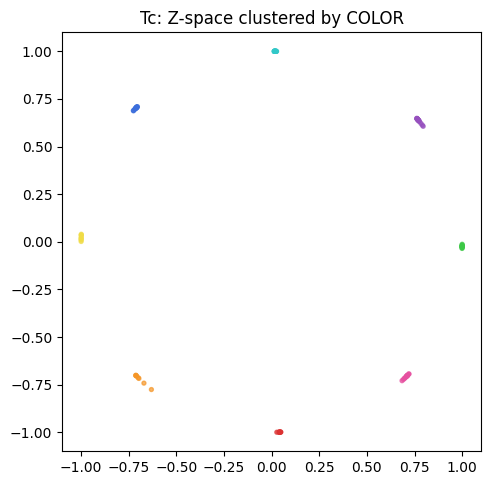

Saved /content/zspace_tc.png


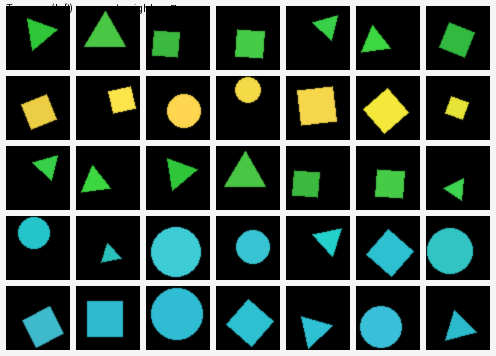

Saved /content/nearest_neighbor_tc.png
Evaluating Ts…


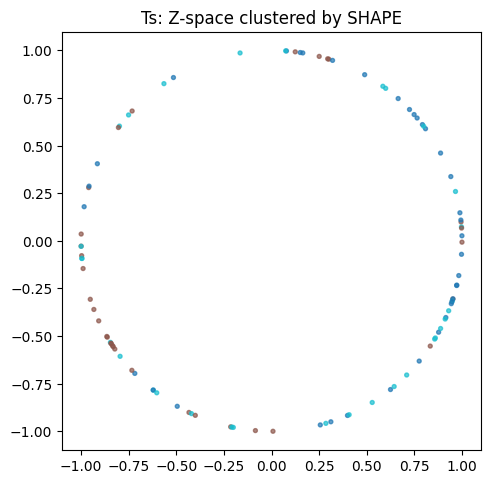

Saved /content/zspace_ts.png


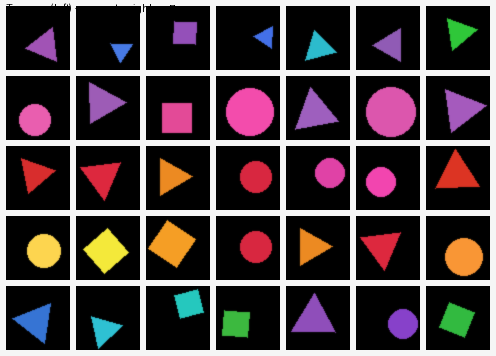

Saved /content/nearest_neighbor_ts.png


In [ ]:

# Tc color cluster
if os.path.exists(CKPT_TC):
    print("Evaluating Tc…")
    model_tc = load_model(CKPT_TC)
    Z_tc, names_tc = embed_paths(model_tc, sample_paths)
    meta_tc = df_meta.loc[names_tc]
    # Scatter colored by color_name
    cols = np.array([np.array(COLOR_RGB[c])/255.0 for c in meta_tc["color_name"]])
    plt.figure(figsize=(5,5))
    plt.scatter(Z_tc[:,0], Z_tc[:,1], s=8, c=cols, alpha=0.7)
    plt.gca().set_aspect('equal','box')
    plt.title("Tc: Z-space clustered by COLOR")
    plt.tight_layout()
    plt.savefig("/content/zspace_tc.png", dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved /content/zspace_tc.png")

    # nearest neighbor panel picks random queries from the sample set
    q_idx = np.random.choice(len(names_tc), size=min(N_QUERIES, len(names_tc)), replace=False)
    panel_tc = make_nn_panel(names_tc, q_idx, Z_tc, k=K_NEIGHBORS, title="Tc: query (left) + nearest neighbors →", out_path="/content/nearest_neighor_tc.png")
    display(panel_tc)
    print("Saved /content/nearest_neighbor_tc.png")
else:
    print("Tc checkpoint not found at", CKPT_TC)

# Ts shape cluster generation
if os.path.exists(CKPT_TS):
    print("Evaluating Ts…")
    model_ts = load_model(CKPT_TS)
    Z_ts, names_ts = embed_paths(model_ts, sample_paths)
    meta_ts = df_meta.loc[names_ts]
    # Scatter colored by SHAPE (cmap)
    c = meta_ts["shape"].map(SHAPE_TO_INT).astype(int).to_numpy()
    plt.figure(figsize=(5,5))
    plt.scatter(Z_ts[:,0], Z_ts[:,1], s=8, c=c, alpha=0.7, cmap="tab10")
    plt.gca().set_aspect('equal','box')
    plt.title("Ts: Z-space clustered by SHAPE")
    plt.tight_layout()
    plt.savefig("/content/zspace_ts.png", dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved /content/zspace_ts.png")

    # Nearest neighbor panel
    q_idx = np.random.choice(len(names_ts), size=min(N_QUERIES, len(names_ts)), replace=False)
    panel_ts = make_nn_panel(names_ts, q_idx, Z_ts, k=K_NEIGHBORS, title="Ts: query (left) + nearest neighbors →", out_path="/content/nearest_neighbor_ts.png")
    display(panel_ts)
    print("Saved /content/nearest_neighbor_ts.png")
else:
    print("Ts checkpoint not found at", CKPT_TS)